# Forecasting Principles and Practice

Load common libraries and settings

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

Load additional libraries

In [4]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

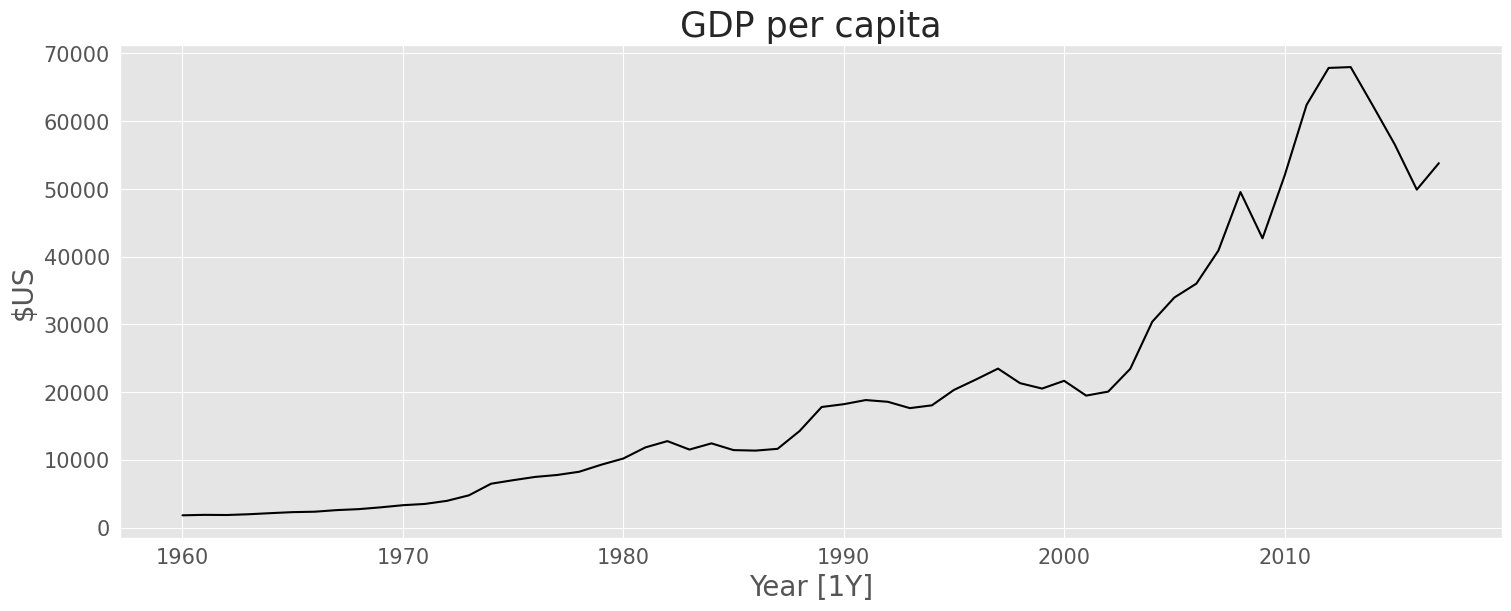

In [5]:
global_economy = pd.read_csv("../data/data_fpppy/global_economy.csv")

df = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(y=lambda x: x["GDP"] / x["Population"])
)
plot_series(df, xlabel="Year [1Y]", ylabel="$US", title="GDP per capita")

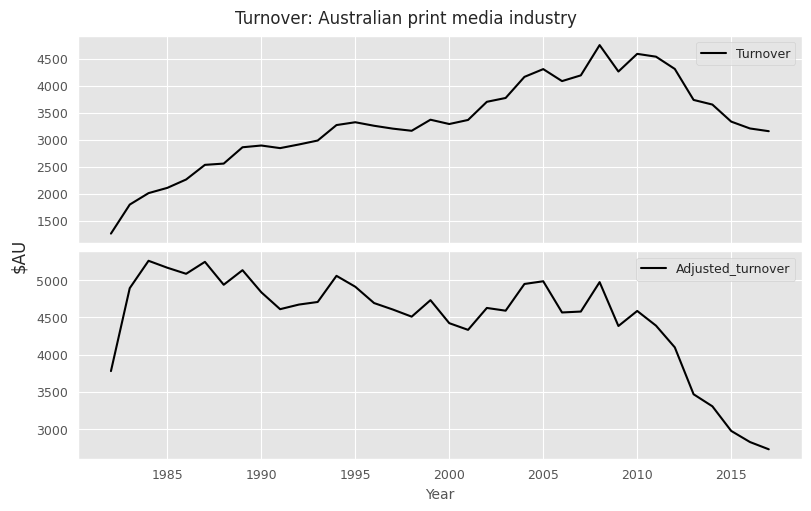

In [7]:
aus_retail = pd.read_csv("../data/data_fpppy/aus_retail.csv", parse_dates=["Month"])
print_retail = (
    aus_retail
    .loc[lambda x: x["Industry"] == "Newspaper and book retailing"]
    .assign(ds=lambda x: x["Month"].dt.year)
    .groupby("ds", as_index=False)
    ["Turnover"].sum()
)
aus_economy = global_economy.loc[lambda x: x["unique_id"] == "Australia"]
df = (
    aus_economy
    .merge(print_retail, on="ds", how="left")
    .assign(adjusted_turnover=lambda x: x["Turnover"] / x["CPI"] * 100)
    .dropna()
)
fig, axes = plt.subplots(2, 1, sharex=True)
sns.lineplot(data=df, x='ds', y='Turnover', ax=axes[0],
    color='black', label="Turnover")
sns.lineplot(data=df, x='ds', y='adjusted_turnover', ax=axes[1],
    color='black', label="Adjusted_turnover")
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel='Year')
fig.suptitle("Turnover: Australian print media industry")
fig.supylabel("$AU")
plt.show()